In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from pathlib import Path

from going_modular.going_modular import utils, engine, data_setup, download_data

d:\Work\Coding\Machine-Learning\PyTorch\going_modular\going_modular\engine.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


## Device agnostic code

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## Download data

In [3]:
## As I have already downloaded data, I am not gonna download it
## but you can download it using the download_data() if you haven't downloaded it yet

## Creating datasets and dataloaders

In [4]:
## Dataset directory

dataset_dir = Path('datasets/pizza_steak_sushi')

train_dir = dataset_dir / 'train'
test_dir = dataset_dir / 'test'


## Create transform

IMG_SIZE = 224

manual_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

## create dataset

BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataloader, test_dataloader, classes = data_setup.create_dataloaders(train_dir=train_dir,
                                                                           test_dir=test_dir,
                                                                           transform=manual_transform,
                                                                           batch_size=BATCH_SIZE,
                                                                           num_workers=NUM_WORKERS)

train_dataloader, test_dataloader, classes

(<torch.utils.data.dataloader.DataLoader at 0x289a9802d50>,
 ['pizza', 'steak', 'sushi'])

## Visualize a single image

torch.Size([3, 224, 224]) tensor(1)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

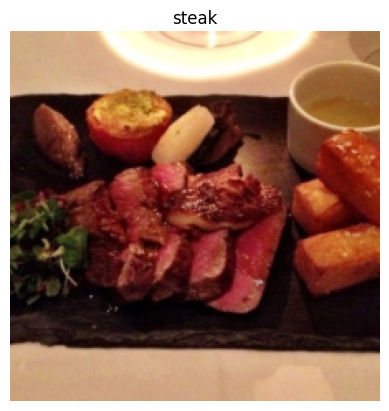

In [5]:
images, labels = next(iter(train_dataloader))

image = images[0]
label = labels[0]

print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)

## Calculating the patch embedding input and output shape by hand

In [6]:
height = 224
width = 224
color_channels = 3
patch_size = 16

num_of_patches = int((height * width) / (pow(patch_size, 2)))
print(f"Number of patchs (N) with image (height={height} and width={width}) and (patch size={patch_size}): {num_of_patches}")

Number of patchs (N) with image (height=224 and width=224) and (patch size=16): 196


In [7]:
embedding_layer_input_shape =  (height, width, color_channels)
embedding_layer_output_shape = (num_of_patches, patch_size*patch_size*color_channels)

print(f"input shape (single 2d image): {embedding_layer_input_shape}")
print(f"output shape (single 2d image flattened into patches): {embedding_layer_output_shape}")

input shape (single 2d image): (224, 224, 3)
output shape (single 2d image flattened into patches): (196, 768)


torch.Size([3, 224, 224]) tensor(1)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

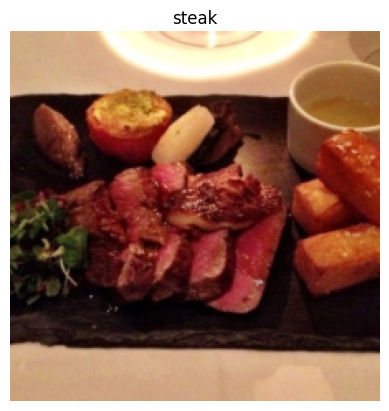

In [8]:
print(image.shape, label)

plt.title(label=classes[label])
plt.imshow(image.permute(1, 2, 0))
plt.axis(False)

## Let's visualize top row

In [9]:
image.permute(1, 2, 0)[:, :, :3].shape

torch.Size([224, 224, 3])

(np.float64(-0.5), np.float64(223.5), np.float64(15.5), np.float64(-0.5))

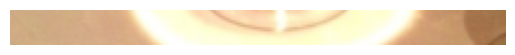

In [10]:
permuted_image = image.permute(1, 2, 0)

patch_size = 16

plt.imshow(permuted_image[:patch_size, :, :3])
plt.axis(False)

## Now create patches for the top row

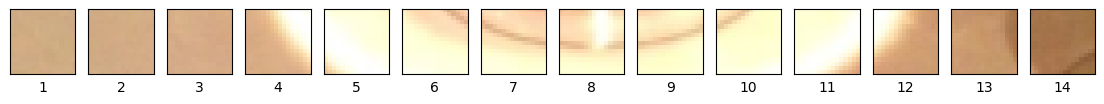

In [11]:
patch_size = 16

num_of_patches = width / patch_size

fig, axis = plt.subplots(nrows=1,
                         ncols= width // patch_size,
                         figsize=(num_of_patches, num_of_patches),
                         sharex=True,
                         sharey=True)


start_iter_patch = 0
end_iter_patch = patch_size

for i in range(0, width//patch_size):

    axis[i].imshow(permuted_image[:patch_size, start_iter_patch: end_iter_patch, :])
    axis[i].set_xlabel(i+1)
    axis[i].set_xticks([])
    axis[i].set_yticks([])
    
    start_iter_patch += patch_size
    end_iter_patch += patch_size
    

## Create whole image patches

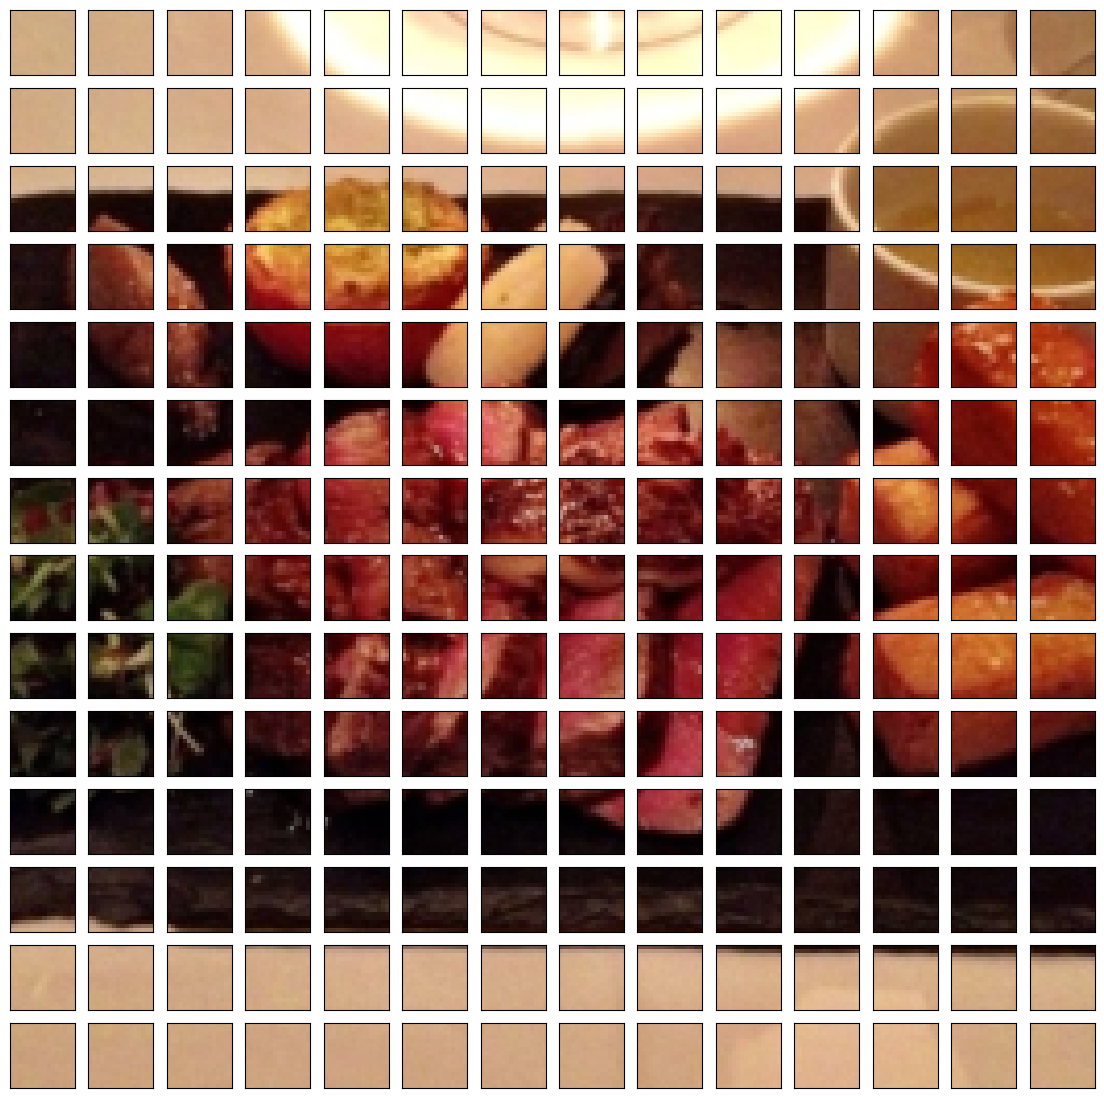

In [12]:
patch_size = 16

num_of_patches = width / patch_size

fig, axis = plt.subplots(nrows= height // patch_size,
                         ncols= width // patch_size,
                         figsize=(num_of_patches, num_of_patches),
                         sharex=True,
                         sharey=True)


height_iter_patch = 0

for i in range(0, height//patch_size):

    width_iter_patch = 0

    for j in range(0, width//patch_size):

        axis[i, j].imshow(permuted_image[height_iter_patch:height_iter_patch+patch_size, width_iter_patch: width_iter_patch+patch_size, :])
        axis[i, j].set_xticks([])
        axis[i, j].set_yticks([])
        width_iter_patch += patch_size
    
    height_iter_patch += patch_size

### What are these diffierent shapes, let's try to understand it

* So first of all we have an image with the size of [224, 224, 3] **224 height**---**224 width**---**3 channels**

* We create patches from these images and one patch size is [16, 16, 3] **16 hieght**--- **16 width**---**3 channels**

* In total we get **`196`** patches.

<details>

<summary>How to calculate patches?</summary>

---

* Divide patch height with image height

    ```python
    224 / 16 = 14
    ```

* Divide patch width with image width

    ```python
    224 / 16 = 14
    ```

* Multiply results

    ```python
    14 * 14 = 196
    ```

---

</details>
    
* After we flatten image we get this shape `[196, 768]`

* **Flatten is basically an operation in which we convert the n-dimensions into vector, data remains same only shape change**

<details>

<summary>How to calculate the faltten image shape</summary>

---

* First we have total patches `196` and we already now how to calculate it

* Secondly we have value 768 and this is came from only one patch shape of `[16*16*3]`

    ```python
    16 * 16 * 3 = 768
    ```
---

</details>

In [13]:
14*14, 16*16*3

(196, 768)

## create conv2d layer

In [14]:
patch_size = 16

conv2d = nn.Conv2d(in_channels=3,
                   out_channels=768,
                   kernel_size=patch_size,
                   stride=patch_size,
                   padding=0)

In [15]:
image_out_of_conv = conv2d((image).unsqueeze(dim=0))
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

torch.Size([1, 14, 14])

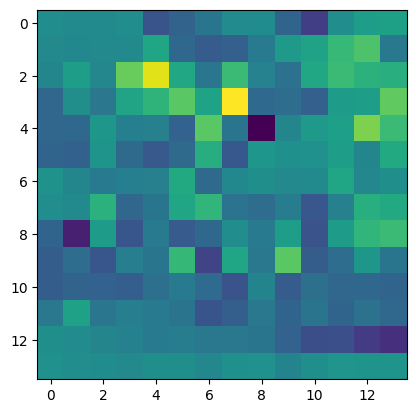

In [16]:
image_conv_feature_map = image_out_of_conv[:, 0, :, :]
plt.imshow(image_conv_feature_map.detach().numpy().squeeze())
image_conv_feature_map.shape

## Let's visualize 5 different feature maps

Showing random convolutional feature maps from indexes: [120, 46, 290, 234, 291]


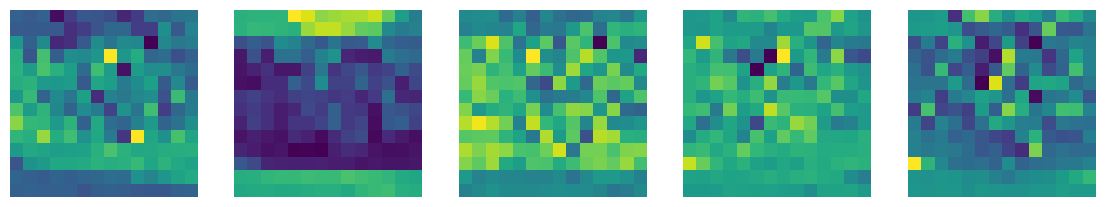

In [17]:
import random

random_idx = random.sample(range(0, 768), k=5)
print(f"Showing random convolutional feature maps from indexes: {random_idx}")

fig, axs = plt.subplots(
    nrows=1,
    ncols=len(random_idx),
    figsize=(14, 14)
)

for i, idx in enumerate(random_idx):

    image_conv_feature_map = image_out_of_conv[:, idx, :, :]
    axs[i].imshow(image_conv_feature_map.detach().numpy().squeeze())
    axs[i].axis(False)

In [18]:
image_out_of_conv.shape

torch.Size([1, 768, 14, 14])

## create faltten layer

In [19]:
## using the 2 and 3 becuase we wanna flatten the spatial dimensions of the feautre map

flatten = nn.Flatten(start_dim=2,
                     end_dim=3)


In [20]:
flatten(image_out_of_conv).permute(0, 2, 1).shape

torch.Size([1, 196, 768])

## Now put these layers together

Original image shape: torch.Size([3, 224, 224])
Image feature map shape: torch.Size([1, 768, 14, 14])
Flattened image feature map shape: torch.Size([1, 768, 196])


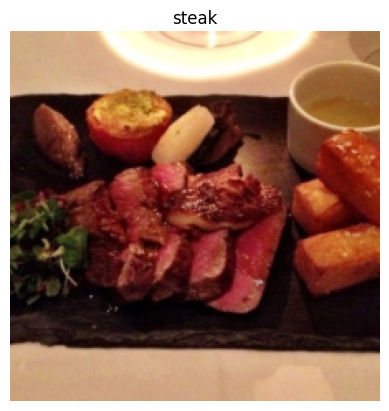

In [21]:
plt.imshow(image.permute(1, 2, 0))
plt.title(classes[label])
plt.axis(False)

print(f"Original image shape: {image.shape}")

image_out_of_conv = conv2d(image.unsqueeze(dim=0))
print(f"Image feature map shape: {image_out_of_conv.shape}")

image_out_of_conv_flattened = flatten(image_out_of_conv)
print(f"Flattened image feature map shape: {image_out_of_conv_flattened.shape}")

In [22]:
image_out_of_conv_flattened_reshaped = image_out_of_conv_flattened.permute(0, 2, 1)
image_out_of_conv_flattened_reshaped.shape

torch.Size([1, 196, 768])

## Visualize one of the flattened feature map

(np.float64(-0.5), np.float64(195.5), np.float64(0.5), np.float64(-0.5))

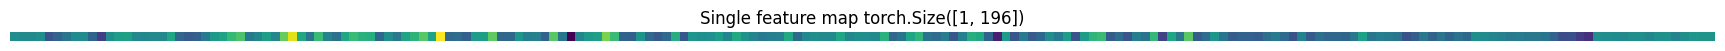

In [23]:
single_feature_map = image_out_of_conv_flattened_reshaped[:, :, 0]

plt.figure(figsize=(22, 22))
plt.title(f"Single feature map {(single_feature_map.shape)}")
plt.imshow(single_feature_map.detach().numpy())
plt.axis(False)

In [24]:
single_feature_map, single_feature_map.requires_grad, single_feature_map.shape

(tensor([[ 0.1040,  0.0968,  0.0982,  0.1034,  0.0037,  0.0284,  0.0603,  0.1006,
           0.1015,  0.0312, -0.0289,  0.1039,  0.1345,  0.1387,  0.0955,  0.0935,
           0.0954,  0.0968,  0.1491,  0.0370,  0.0164,  0.0230,  0.0712,  0.1261,
           0.1410,  0.1827,  0.2043,  0.0664,  0.0903,  0.1349,  0.0919,  0.2250,
           0.3065,  0.1492,  0.0618,  0.1867,  0.0830,  0.0538,  0.1494,  0.1884,
           0.1700,  0.1655,  0.0339,  0.1062,  0.0635,  0.1446,  0.1740,  0.2145,
           0.1432,  0.3267,  0.0395,  0.0458,  0.0239,  0.1304,  0.1330,  0.2207,
           0.0339,  0.0364,  0.1205,  0.0775,  0.0793,  0.0268,  0.2145,  0.0594,
          -0.1103,  0.0911,  0.1245,  0.1365,  0.2411,  0.1867,  0.0312,  0.0250,
           0.1155,  0.0416,  0.0111,  0.0402,  0.1623,  0.0096,  0.1199,  0.1094,
           0.1104,  0.1324,  0.0906,  0.1556,  0.1118,  0.0895,  0.0688,  0.0788,
           0.0806,  0.1558,  0.0406,  0.0933,  0.1071,  0.0948,  0.0969,  0.1465,
           0.091

## Time to create the ViT patch embedding layer into pytorch module

In [30]:
class PatchEmbedding(nn.Module):

    def __init__(self, patch_size, in_channels, out_channels, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.patcher = nn.Conv2d(in_channels=in_channels,
                           out_channels=out_channels,
                           kernel_size=patch_size,
                           stride=patch_size,
                           padding=0)
        
        self.flatten = nn.Flatten(start_dim=2,
                             end_dim=3)
        
    def forward(self, x):

        image_resolution = x.shape[-1]

        assert image_resolution % patch_size == 0, f"Image size must be divisible by patch size, image shape: {image_resolution}, patch_size: {patch_size}"

        return self.flatten(self.patcher(x)).permute(0, 2, 1)

In [33]:
patchEmbedding = PatchEmbedding(patch_size=16,
                                in_channels=3,
                                out_channels=768)

patchEmbedding

PatchEmbedding(
  (patcher): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (flatten): Flatten(start_dim=2, end_dim=3)
)

In [34]:
patch_embedding = patchEmbedding(image.unsqueeze(dim=0))
patch_embedding.shape

torch.Size([1, 196, 768])

## Now we create CLS token and put it in front of the patches

In [155]:
BATCH_SIZE = patch_embedding.shape[0]
patch_embedding_dimension = patch_embedding.shape[-1]

class_token = nn.Parameter(torch.ones(BATCH_SIZE, 1, patch_embedding_dimension),
                           requires_grad=True)

class_token.shape

torch.Size([1, 1, 768])

In [228]:
torch.cat((class_token, patch_embedding), dim=1).shape

torch.Size([1, 197, 768])

In [45]:
8*8*3

192